In [1]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training.npy')
y_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training_labels.npy')
X_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test.npy')
y_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test_labels.npy')

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM, Dropout, Conv1D, Layer, MultiHeadAttention
from tensorflow.keras.layers import LayerNormalization, GlobalAveragePooling1D, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, rate=0.25):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads,
                                      key_dim=embed_dim)
        self.ffn = Sequential([
            Conv1D(128, 3, padding='same'),

            Dense(128, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)  # self-attention layer
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)  # layer norm
        ffn_output = self.ffn(out1)  #feed-forward layer
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)  # layer norm


class TokenAndPositionEmbedding(Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size,
                                   output_dim=embed_dim)
        self.pos_emb = Embedding(input_dim=maxlen + 1,  # vocab size, including the 0-th word used for padding
                       output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [22]:
embed_dim = 128  # Embedding size for each token
num_heads = 3  # Number of attention heads
maxlen = 300
vocab_size = 52145

model = Sequential()
model.add(Input(shape=(maxlen, )))
model.add(TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim))
model.add(Conv1D(128,3))
model.add(TransformerBlock(embed_dim, num_heads))
model.add(GlobalAveragePooling1D())
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer="adam",
              metrics=['accuracy'])

model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 token_and_position_embeddi  (None, 300, 128)          6713088   
 ng_4 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 conv1d_3 (Conv1D)           (None, 298, 128)          49280     
                                                                 
 transformer_block_6 (Trans  (None, 298, 128)          280704    
 formerBlock)                                                    
                                                                 
 global_average_pooling1d_4  (None, 128)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dropout_22 (Dropout)        (None, 128)             

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)

history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1,
                    callbacks= callbacks)

Epoch 1/100
22/22 [==============================] - 22s 798ms/step - loss: 0.7087 - accuracy: 0.5427 - val_loss: 0.8582 - val_accuracy: 0.1180
Epoch 2/100
22/22 [==============================] - 15s 691ms/step - loss: 0.5655 - accuracy: 0.7030 - val_loss: 0.3227 - val_accuracy: 0.9028
Epoch 3/100
22/22 [==============================] - 15s 672ms/step - loss: 0.2993 - accuracy: 0.8770 - val_loss: 0.6178 - val_accuracy: 0.7452
Epoch 4/100
22/22 [==============================] - 14s 660ms/step - loss: 0.1699 - accuracy: 0.9376 - val_loss: 0.4360 - val_accuracy: 0.8392
Epoch 5/100
22/22 [==============================] - 15s 663ms/step - loss: 0.1031 - accuracy: 0.9674 - val_loss: 1.0940 - val_accuracy: 0.7076
Epoch 6/100
22/22 [==============================] - 15s 679ms/step - loss: 0.0672 - accuracy: 0.9780 - val_loss: 1.5598 - val_accuracy: 0.6272
Epoch 7/100
22/22 [==============================] - 15s 676ms/step - loss: 0.0447 - accuracy: 0.9868 - val_loss: 0.9699 - val_accuracy:

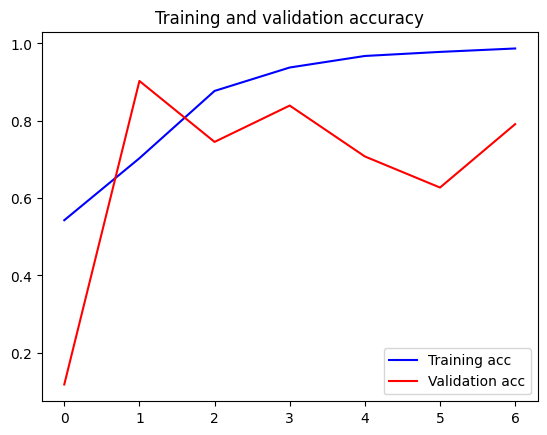

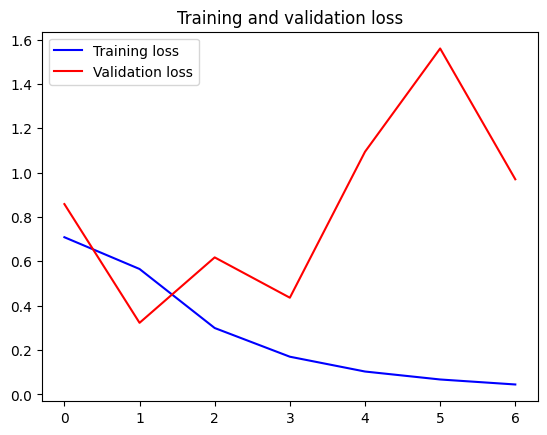

In [24]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [25]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

25/25 [==============================] - 6s 229ms/step - loss: 0.6916 - accuracy: 0.8496

ACCURACY: 0.8495540022850037
LOSS: 0.6915518641471863
